(1500, 1000, 3)


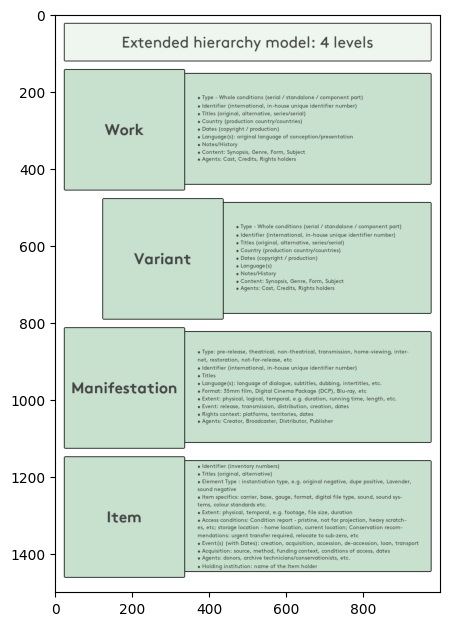

In [61]:
# notebook to work on opencv diagrams for FIAF cat manual.

import cv2
import matplotlib.pylab as plt
import numpy
import pathlib
import skimage
from PIL import Image, ImageDraw, ImageFont


def font(weight, size):

    ''' Define a font object. '''

    font_path = pathlib.Path.cwd().parents[0] / 'font' / f'BrownStd{weight}.otf'
    if not font_path.exists():
        raise Exception('Font OTF does not exist.')
    
    return ImageFont.truetype(str(font_path), size)

def draw_rectangle(name, x, y, w, h, colour):
    
    ''' Define a rectangle shape. '''

    cv2.rectangle(canvas, (x, y), (x+w, y+h), (0,0,0), 4) 
    cv2.rectangle(canvas, (x, y), (x+w, y+h), colour, -1) 
    elements[name] = {'x':x, 'y':y, 'w':w, 'h':h}

def draw_text_by_anchor(anchor, text, text_weight, text_size, center, y_offset_iterate, x_offset_manual):

    font_object = font(text_weight, text_size)

   
    anchor_coords = elements[anchor]
    center_x = anchor_coords['x']+(anchor_coords['w']/2)
    center_y = anchor_coords['y']+(anchor_coords['h']/2)

    text_bbox = font_object.getbbox(text[:4])
    center_y = center_y-(text_bbox[3]/2)

    center_y = center_y + (y_offset_iterate*20)

    center_x = center_x+x_offset_manual

    if center:
        text_bbox = font_object.getbbox(text)
        center_x = center_x-(text_bbox[2]/2)

   


    draw.text((int(center_x), int(center_y)), text, font=font_object, fill="#444444")

def render_preview(path):

    preview = cv2.cvtColor(cv2.imread(path, -1), cv2.COLOR_BGR2RGB) 
    print(preview.shape)
    plt.figure(figsize=(7.5,7.5))
    plt.imshow(skimage.img_as_float32(preview))
    plt.show()  

img_path = pathlib.Path.cwd() / 'test.png'

canvas_w, canvas_h = 1000, 1500
canvas = numpy.zeros((canvas_h, canvas_w, 3), numpy.uint8)
canvas[:, :] = (255, 255, 255)

elements = dict()
draw_rectangle('header', 25, 25, 950, 95, (239, 246, 238))

draw_rectangle('layer_1', 125, 155, 850, 285, (206, 225, 199))
draw_rectangle('layer_2', 125, 490, 850, 285, (206, 225, 199))
draw_rectangle('layer_3', 125, 825, 850, 285, (206, 225, 199))
draw_rectangle('layer_4', 125, 1160, 850, 285, (206, 225, 199))

# draw_rectangle('box_1_shadow', 25+5, 145+5, 300, 300, (0, 0, 0))

draw_rectangle('box_1', 25, 145, 310, 310, (206, 225, 199))
draw_rectangle('box_2', 125, 480, 310, 310, (206, 225, 199))
draw_rectangle('box_3', 25, 815, 310, 310, (206, 225, 199))
draw_rectangle('box_4', 25, 1150, 310, 310, (206, 225, 199))


# cv2.dottedLine(canvas, (25,825), (25, 1160), (0,0,255), 2)


cv2.imwrite(img_path, canvas)

image_data = Image.open(img_path)
draw = ImageDraw.Draw(image_data)



draw_text_by_anchor('header', 'Extended hierarchy model: 4 levels', 'Regular', 40, True, 0, 0)


# mathematically calculate offsets.


layer_1_text = ['• Type - Whole conditions (serial / standalone / component part)',
    '• Identifier (international, in-house unique identifier number)',
    '• Titles (original, alternative, series/serial)',
    '• Country (production country/countries)',
    '• Dates (copyright / production)',
    '• Language(s): original language of conception/presentation',
    '• Notes/History',
    '• Content: Synopsis, Genre, Form, Subject',
    '• Agents: Cast, Credits, Rights holders']

layer_1_text = [{'text':x, 'offset':i-((len(layer_1_text)-1)/2)} for i,x in enumerate(layer_1_text)]
for x in layer_1_text:
    draw_text_by_anchor('layer_1', x['text'], 'Regular', 14, False, x['offset'], -180)


layer_2_text = [
    '• Type - Whole conditions (serial / standalone / component part)',
    '• Identifier (international, in-house unique identifier number)',
    '• Titles (original, alternative, series/serial)',
    '• Country (production country/countries)',
    '• Dates (copyright / production)',
    '• Language(s)',
    '• Notes/History',
    '• Content: Synopsis, Genre, Form, Subject',
    '• Agents: Cast, Credits, Rights holders'
]

layer_2_text = [{'text':x, 'offset':i-((len(layer_2_text)-1)/2)} for i,x in enumerate(layer_2_text)]
for x in layer_2_text:
    draw_text_by_anchor('layer_2', x['text'], 'Regular', 14, False, x['offset'], -80)


layer_3_text = [
    '• Type: pre-release, theatrical, non-theatrical, transmission, home-viewing, inter-',
    'net, restoration, not-for-release, etc',
    '• Identifier (international, in-house unique identifier number)',
    '• Titles',
    '• Language(s): language of dialogue, subtitles, dubbing, intertitles, etc.',
    '• Format: 35mm film, Digital Cinema Package (DCP), Blu-ray, etc',
    '• Extent: physical, logical, temporal, e.g. duration, running time, length, etc.',
    '• Event: release, transmission, distribution, creation, dates',
    '• Rights context: platforms, territories, dates',
    '• Agents: Creator, Broadcaster, Distributor, Publisher'
]

layer_3_text = [{'text':x, 'offset':i-((len(layer_3_text)-1)/2)} for i,x in enumerate(layer_3_text)]
for x in layer_3_text:
    draw_text_by_anchor('layer_3', x['text'], 'Regular', 14, False, x['offset'], -180)

layer_4_text = [
'• Identifier (inventory numbers)',
'• Titles (original, alternative)',
'• Element Type : instantiation type, e.g. original negative, dupe positive, Lavender,',
'sound negative',
'• Item specifics: carrier, base, gauge, format, digital file type, sound, sound sys-',
'tems, colour standards etc.',
'• Extent: physical, temporal, e.g. footage, file size, duration',
'• Access conditions: Condition report - pristine, not for projection, heavy scratch-',
'es, etc; storage location - home location, current location; Conservation recom-',
'mendations: urgent transfer required, relocate to sub-zero, etc',
'• Event(s) (with Dates): creation, acquisition, accession, de-accession, loan, transport',
'• Acquisition: source, method, funding context, conditions of access, dates',
'• Agents: donors, archive technicians/conservationists, etc.',
'• Holding institution: name of the Item holder'
]

layer_4_text = [{'text':x, 'offset':i-((len(layer_4_text)-1)/2)} for i,x in enumerate(layer_4_text)]
for x in layer_4_text:
    draw_text_by_anchor('layer_4', x['text'], 'Regular', 14, False, x['offset'], -180)


draw_text_by_anchor('box_1', 'Work', 'Bold', 40, True, 0, 0)
draw_text_by_anchor('box_2', 'Variant', 'Bold', 40, True, 0, 0)
draw_text_by_anchor('box_3', 'Manifestation', 'Bold', 40, True, 0, 0)
draw_text_by_anchor('box_4', 'Item', 'Bold', 40, True, 0, 0)



image_data.save(img_path)




render_preview(img_path)

In [9]:
(950/1253)*400

303.2721468475658